# Florentine families

In [30]:
import sys
import os
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import jax
import jax.numpy as jnp
import jax.scipy as jsp
import pickle

## Network

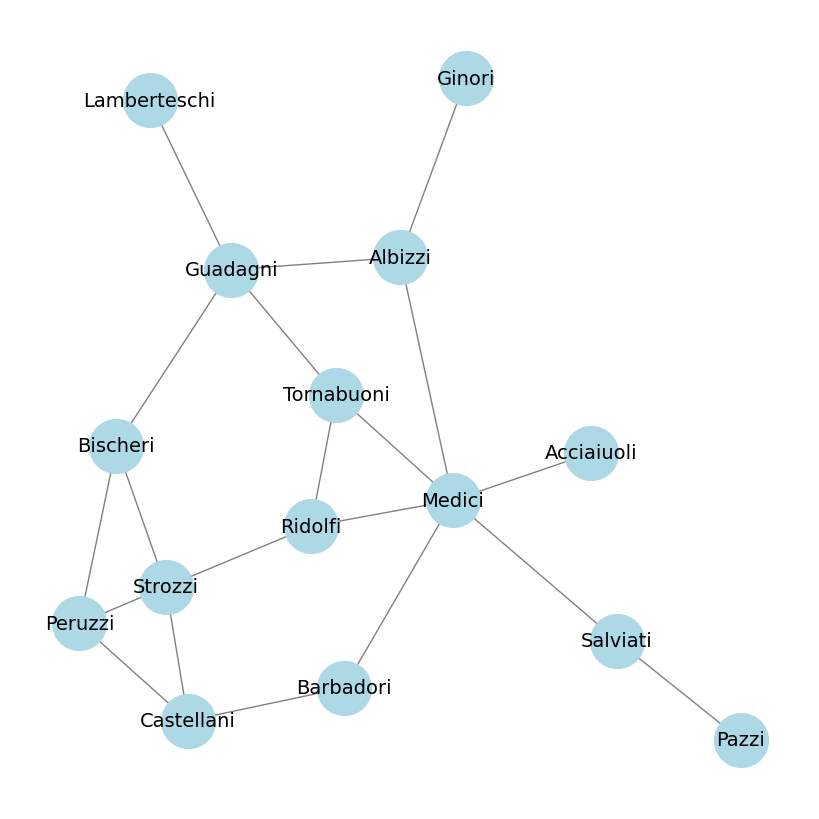

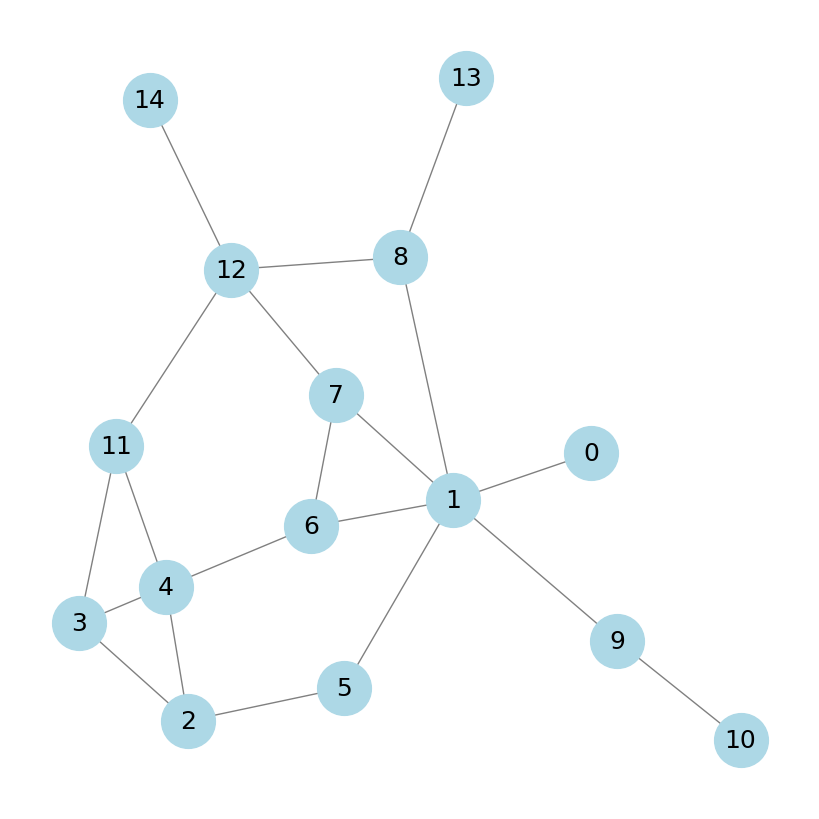

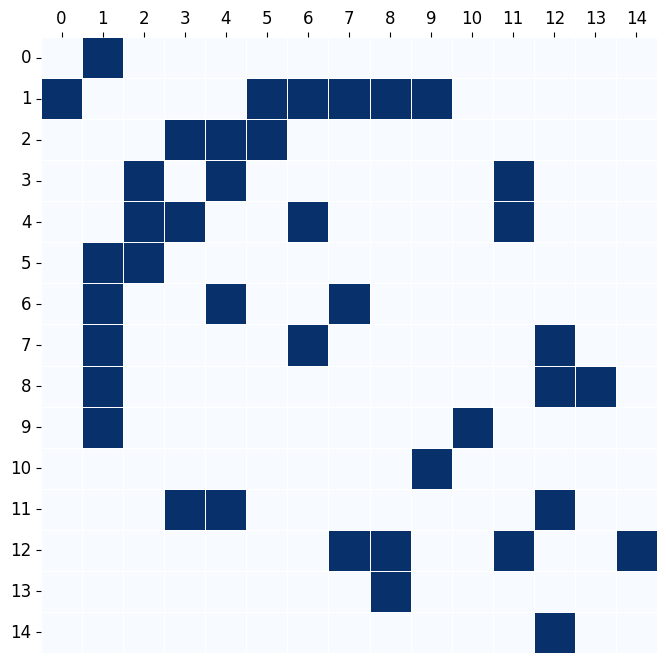

In [2]:
G = nx.florentine_families_graph()
pos = nx.spring_layout(G, seed=80)
plt.figure(figsize=(8,8))
nx.draw(G, pos=pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=1500, font_size=14)
#plt.title("Florentine Families network")
plt.show()

G = nx.florentine_families_graph()
node_mapping = {node: i for i, node in enumerate(G.nodes())}
G = nx.relabel_nodes(G, node_mapping)
plt.figure(figsize=(8,8))
pos_relabel = {node_mapping[k]: v for k, v in pos.items()}
nx.draw(G,  pos=pos_relabel, with_labels=True, node_color='lightblue', edge_color='gray', node_size=1500, font_size=18)
#plt.title("Florentine Families network with relabeled nodes")
plt.show()
#print("Map from original nodes to new nodes:")
#print(node_mapping)

Y = nx.to_numpy_array(G, dtype=float)
plt.figure(figsize=(8,8))
sns.heatmap(Y, annot=False, cmap="Blues", cbar=False, square=True, linewidths=0.5, linecolor='white')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.gca().xaxis.tick_top() 
plt.gca().tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, labelsize=12)
#plt.title("Sociomatrix for Florentine families")
plt.show() 

## Code

### Geometry

Base

In [3]:
class Geometry:
    def distance(self, zi, zj):
        raise NotImplementedError
    def distance_matrix(self, Z):
        raise NotImplementedError
    def project_to_tangent(self, z, v):
        raise NotImplementedError
    def project_to_domain(self, z):
        raise NotImplementedError
    def logaritmic_map(self, z, zp):
        raise NotImplementedError
    def exponential_map(self, z, v):
        raise NotImplementedError
    def identifiability_transform(self, Z, Z_ref):
        raise NotImplementedError
    def sample_uniform_Z(self, n:int, seed:int):
        raise NotImplementedError

Simplex

In [4]:
class Simplex:
    def __init__(self, n):
        self.n = n
        self.project_to_tangent = jax.jit(self._project_to_tangent)
        self.project_to_domain = jax.jit(self._project_to_domain)
        self.exponential_map   = jax.jit(self._exponential_map)

    # Tangent projection
    def _project_to_tangent(self, xi, v):
        mean_v = jnp.mean(v)
        return v - mean_v

    # Projection to simplex
    def _project_to_domain(self, xi):
        xi = jnp.maximum(xi, 1e-12)
        return self.n * xi / jnp.sum(xi)

    # Exponential map 
    def _exponential_map(self, xi, v):
        xi_new = xi * jnp.exp(v)
        return self.n * xi_new / jnp.sum(xi_new)

Euclidean

In [5]:
class EuclideanGeometry(Geometry):
    def __init__(self, d, D=None):
        self.d = d
        self.D = D  
        self.distance = jax.jit(self._distance)
        self.distance_matrix = jax.jit(self._distance_matrix)
        self.project_to_tangent = jax.jit(self._project_to_tangent)
        self.project_to_domain = jax.jit(self._project_to_domain)
        self.logaritmic_map = jax.jit(self._logaritmic_map)
        self.exponential_map = jax.jit(self._exponential_map)
        self.identifiability_transform = jax.jit(self._identifiability_transform)
        self.grad_distance = jax.jit(jax.grad(self._distance, argnums=0))

    # distance 
    def _distance(self, zi, zj):
        diff = zi - zj
        return jnp.sqrt(jnp.sum(diff**2) + 1e-12)
    
    # distance matrix
    def _distance_matrix(self, Z):
        diff = Z[:, None, :] - Z[None, :, :]
        return jnp.sqrt(jnp.sum(diff**2, axis=-1) + 1e-12)
    
    # tangent projection 
    def _project_to_tangent(self, z, v):
        return v
    
    # domain projection
    def _project_to_domain(self, z):
        if self.D is None:
            return z
        radius = self.D / 2.0
        norm = jnp.linalg.norm(z)
        factor = jnp.minimum(1.0, radius / (norm + 1e-12))
        return z * factor
    
    #logaritmic map
    def _logaritmic_map(self, z, zp):
        v = zp - z
        return v
    
    # exponential map 
    def _exponential_map(self, z, v):
        y = z + v
        return y 
    
    # identifiability
    def _identifiability_transform(self, Z, Z_ref):
        # center configurations
        Z_mean = jnp.mean(Z, axis=0, keepdims=True)
        Z_ref_mean = jnp.mean(Z_ref, axis=0, keepdims=True)
        Zc = Z - Z_mean
        Z_refc = Z_ref - Z_ref_mean
        # cross-covariance matrix
        M = Zc.T @ Z_refc
        # SVD
        U, _, Vt = jnp.linalg.svd(M, full_matrices=False)
        # optimal orthogonal transformation
        R = Vt.T @ U.T
        # avoid improper rotations (reflection)
        detR = jnp.linalg.det(R)
        correction = jnp.eye(self.d)
        correction = correction.at[-1, -1].set(jnp.sign(detR))
        R = Vt.T @ correction @ U.T
        # aligned configuration
        Z_aligned = Zc @ R
        # recenter to reference centroid
        Z_aligned = Z_aligned + Z_ref_mean
        return Z_aligned
    
    # sampling
    def sample_uniform_Z(self, n: int, key):
        if self.D is None:
            return jax.random.normal(key, shape=(n, self.d))
        R = self.D / 2.0
        key1, key2 = jax.random.split(key)
        # random directions on sphere
        X = jax.random.normal(key1, shape=(n, self.d))
        norms = jnp.linalg.norm(X, axis=1, keepdims=True) + 1e-12
        directions = X / norms
        # radial law for uniform volume measure in ball
        u = jax.random.uniform(key2, shape=(n, 1))
        radii = R * (u ** (1.0 / self.d))
        return directions * radii

Spherical

In [6]:
class SphericalGeometry(Geometry):
    def __init__(self, d, D = jnp.pi):
        self.d = d
        self.D = D
        self.R = D / jnp.pi
        self.distance = jax.jit(self._distance)
        self.distance_matrix = jax.jit(self._distance_matrix)
        self.project_to_tangent = jax.jit(self._project_to_tangent)
        self.project_to_domain = jax.jit(self._project_to_domain)
        self.logaritmic_map = jax.jit(self._logaritmic_map)
        self.exponential_map = jax.jit(self._exponential_map)
        self.identifiability_transform = jax.jit(self._identifiability_transform)
        self.grad_distance = jax.jit(jax.grad(self._distance, argnums=0))
    
    # distance on S^d(R) 
    def _distance(self, zi, zj):
        dot = jnp.dot(zi, zj) / (self.R**2)
        dot = jnp.clip(dot, -1.0 + 1e-7, 1.0 - 1e-7)
        return self.R * jnp.arccos(dot)
    
    # distance matrix 
    def _distance_matrix(self, Z):
        dot = (Z @ Z.T) / (self.R**2)
        dot = jnp.clip(dot, -1.0 + 1e-7, 1.0 - 1e-7)
        return self.R * jnp.arccos(dot)
    
    #logaritmic map
    def _logaritmic_map(self, z, zp):
        dot = jnp.clip(jnp.dot(z, zp) / (self.R**2), -1.0 + 1e-12, 1.0 - 1e-12)
        theta = jnp.arccos(dot)
        sin_theta = jnp.sin(theta)
        factor = theta / (sin_theta + 1e-12)
        v = factor * (zp - dot * z)
        return v
    
    # projection to tangent space 
    def _project_to_tangent(self, z, v):
        return v - (jnp.dot(z, v) / (self.R**2)) * z
    
    # domain projection
    def _project_to_domain(self, z):
        norm = jnp.linalg.norm(z) + 1e-12
        return self.R * z / norm
  
    
    # exponential map 
    def _exponential_map(self, z, v):
        norm_v = jnp.linalg.norm(v)
        eps = 1e-12
        coef1 = jnp.cos(norm_v / self.R)
        coef2 = jnp.sin(norm_v / self.R) / (norm_v + eps)
        y = coef1 * z + coef2 * v
        return y    
    
    # identifiability 
    def _identifiability_transform(self, Z, Z_ref):
        # cross-covariance matrix
        M = Z.T @ Z_ref
        # SVD decomposition
        U, _, Vt = jnp.linalg.svd(M, full_matrices=False)
        # optimal orthogonal matrix
        Q = Vt.T @ U.T
        # avoid reflections
        detQ = jnp.linalg.det(Q)
        correction = jnp.eye(self.d + 1)
        correction = correction.at[-1, -1].set(jnp.sign(detQ))
        Q = Vt.T @ correction @ U.T
        # rotate configuration
        Z_aligned = Z @ Q
        # numerical reprojection onto sphere
        norms = jnp.linalg.norm(Z_aligned, axis=1, keepdims=True) + 1e-12
        Z_aligned = self.R * Z_aligned / norms
        return Z_aligned
    
    #sampling
    def sample_uniform_Z(self, n: int, key):
        X = jax.random.normal(key, shape=(n, self.d + 1))
        norms = jnp.linalg.norm(X, axis=1, keepdims=True) + 1e-12
        Z = self.R * X / norms
        return Z

Hyperbolic

In [16]:
class HyperbolicGeometry(Geometry):
    def __init__(self, d, D=None):
        self.d = d
        self.D = D
        self.R = D / jnp.pi if D is not None else 1.0
        self.distance = jax.jit(self._distance)
        self.distance_matrix = jax.jit(self._distance_matrix)
        self.project_to_tangent = jax.jit(self._project_to_tangent)
        self.project_to_domain = jax.jit(self._project_to_domain)
        self.logaritmic_map = jax.jit(self._logaritmic_map)
        self.exponential_map = jax.jit(self._exponential_map)
        self.identifiability_transform = jax.jit(self._identifiability_transform)
        self.grad_distance = jax.jit(jax.grad(self._distance, argnums=0))

    # Lorentz inner product 
    def _lorentz_inner(self, zi, zj):
        return jnp.dot(zi[:-1], zj[:-1]) - zi[-1] * zj[-1]
    
    # distance
    def _distance(self, zi, zj):
        inner = self._lorentz_inner(zi, zj)
        x = -inner / (self.R**2)
        x = jnp.clip(x, 1.0 + 1e-7, None)
        return self.R * jnp.arccosh(x)
    
    # distance matrix
    def _distance_matrix(self, Z):
        spatial = Z[:, :-1]
        time = Z[:, -1]
        inner = spatial @ spatial.T - jnp.outer(time, time)
        x = -inner / (self.R**2)
        x = jnp.maximum(x, 1.0 + 1e-7)
        return self.R * jnp.arccosh(x)
    
    # projection to tangent 
    def _project_to_tangent(self, z, v):
        # T_z H^d = {v : <z,v>_L = 0}
        inner = self._lorentz_inner(z, v)
        return v + (inner / (self.R**2)) * z
    
    # domain projection
    def _project_to_domain(self, z):
        x = z[:-1]
        spatial_norm_sq = jnp.sum(x**2)
        t = jnp.sqrt(self.R**2 + spatial_norm_sq)
        z = jnp.concatenate([x, jnp.array([t])])
        t_max = self.R * jnp.cosh(self.D / (2 * self.R))
        x = z[:-1]
        t = z[-1]
        def inside():
            return z
        def outside():
            norm_x = jnp.linalg.norm(x) + 1e-12
            new_norm = jnp.sqrt(t_max**2 - self.R**2)
            factor = new_norm / norm_x
            x_new = x * factor
            return jnp.concatenate([x_new, jnp.array([t_max])])
        return jax.lax.cond(t <= t_max, inside, outside)
    
    #logaritmic map
    def _logaritmic_map(self, z, zp):
        dot = self._lorentz_inner(z, zp)
        alpha = -dot  # debe ser ≥ 1
        omega = jnp.arccosh(alpha)
        denom = jnp.sqrt(alpha**2 - 1.0 + 1e-12)
        v = (omega / (denom + 1e-12)) * (zp + (dot / (self.R**2)) * z)
        return self._project_to_tangent(z, v)
    
    # exponential map 
    def _exponential_map(self, z, v):
        norm_v_sq = self._lorentz_inner(v, v)
        norm_v = jnp.sqrt(jnp.maximum(norm_v_sq, 1e-12))
        coef1 = jnp.cosh(norm_v / self.R)
        coef2 = jnp.sinh(norm_v / self.R) / (norm_v + 1e-12)
        z_new = coef1 * z + coef2 * v
        return z_new
    
    # identifiability 
    def _identifiability_transform(self, Z, Z_ref):
        p = self.d + 1
        # Minkowski metric
        J = jnp.eye(p)
        J = J.at[-1, -1].set(-1.0)
        # generalized covariance
        M = Z_ref.T @ (Z @ J)
        # Euclidean SVD
        U, _, Vt = jnp.linalg.svd(M, full_matrices=False)
        # candidate Lorentz transform
        Q = U @ Vt
        # enforce Lorentz condition approximately
        # Q^T J Q = J
        A = Q.T @ J @ Q
        # symmetric correction
        eigvals, eigvecs = jnp.linalg.eigh(A)
        inv_sqrt = eigvecs @ jnp.diag(1.0 / jnp.sqrt(jnp.abs(eigvals) + 1e-12)) @ eigvecs.T
        Q = Q @ inv_sqrt
        # aligned configuration
        Z_aligned = Z @ Q.T
        # numerical reprojection onto hyperboloid
        spatial = Z_aligned[:, :-1]
        spatial_norm_sq = jnp.sum(spatial**2, axis=1, keepdims=True)
        time = jnp.sqrt(self.R**2 + spatial_norm_sq)
        Z_aligned = jnp.concatenate([spatial, time], axis=1)
        return Z_aligned
    
    # sampling
    def sample_uniform_Z(self, n: int, key):
        assert self.d in [1, 2], "Exact sampler implemented for d=1 or d=2"
        assert self.D is not None, "Hyperbolic sampling requires finite D"
        R = self.R
        if self.d == 1:
            key1, key2 = jax.random.split(key)
            # random direction in {-1,+1}
            direction = jax.random.choice(key1, jnp.array([-1.0, 1.0]), shape=(n, 1))
            # uniform radius in [0, D/2]
            u = jax.random.uniform(key2, shape=(n, 1))
            r = (self.D / 2.0) * u
        elif self.d == 2:
            key1, key2 = jax.random.split(key)
            # angular direction uniformly on circle
            theta = jax.random.uniform(key1, shape=(n, 1), minval=0.0, maxval=2.0 * jnp.pi)
            direction = jnp.concatenate([jnp.cos(theta), jnp.sin(theta)],axis=1)
            # exact radial law in H^2
            alpha = 1.0
            u = jax.random.uniform(key2, shape=(n, 1))
            r = (1.0 / alpha) * jnp.arccosh(1.0 + u * (jnp.cosh(alpha * (self.D / 2.0)) - 1.0))
        norm = r / R
        cosh_term = jnp.cosh(norm)
        sinh_term = jnp.sinh(norm)
        spatial = R * sinh_term * direction
        time = R * cosh_term
        Z = jnp.concatenate([spatial, time], axis=1)
        return Z

### Likelihood

In [8]:
class LatentSpaceLikelihood:
    def __init__(self, geometry):
        self.geometry = geometry
        self.loglikelihood = jax.jit(self._loglikelihood)
        self.grad_alpha0 = jax.jit(jax.grad(self._loglikelihood, argnums=0))
        self.grad_xi     = jax.jit(jax.grad(self._loglikelihood, argnums=1))
        self.grad_Z      = jax.jit(jax.grad(self._loglikelihood, argnums=2))
    # predictor
    def _predictor(self, alpha0, xi, Z):
        D = self.geometry.distance_matrix(Z)
        xi_i = xi[:, None]
        xi_j = xi[None, :]
        S = alpha0 - 0.5 * (xi_i + xi_j) * D
        return S
    # loglikelihood
    def _loglikelihood(self, alpha0, xi, Z, Y):
        S = self._predictor(alpha0, xi, Z)
        mask = jnp.triu(jnp.ones_like(Y), k=1)
        loglik = Y * S - jax.nn.softplus(S)
        return jnp.sum(loglik * mask)
    # gradients
    def gradients(self, alpha0, xi, Z, Y):
        return {"alpha0": self.grad_alpha0(alpha0, xi, Z, Y), "xi": self.grad_xi(alpha0, xi, Z, Y), "Z": self.grad_Z(alpha0, xi, Z, Y)}

### Prior

In [9]:
class LatentSpacePrior:
    def __init__(self, geometry, sigma2_alpha0=10.0, a_xi=2.0, fixed_params:dict = {}):
        self.sigma2_alpha0 = sigma2_alpha0
        self.a_xi = a_xi
        self.geometry = geometry
        self.fixed_params = fixed_params
        self.fix_alpha0 = "alpha0" in fixed_params
        if self.fix_alpha0:
            self.alpha0_fixed = self.fixed_params.get("alpha0", None)
        self.fix_xi     = "xi" in fixed_params
        if self.fix_xi:
            self.xi_fixed = self.fixed_params.get("xi", None)
        self.fix_Z      = "Z" in fixed_params
        if self.fix_Z:
            self.Z_fixed = self.fixed_params.get("Z", None)
         
        self.log_prior_density = jax.jit(self._log_prior_density)
        self.grad_alpha0 = jax.jit(jax.grad(self._log_prior_density, argnums=0))
        self.grad_xi     = jax.jit(jax.grad(self._log_prior_density, argnums=1))
        self.grad_Z      = jax.jit(jax.grad(self._log_prior_density, argnums=2))
        

    #  log prior 
    def _log_prior_density(self, alpha0, xi, Z):
        logp = 0.0
        # alpha0 ~ N(0, sigma2)
        if not self.fix_alpha0:
            logp += -0.5 * (jnp.log(self.sigma2_alpha0) + alpha0**2 / self.sigma2_alpha0)
        # xi ~ Dirichlet 
        if not self.fix_xi:
            xi_safe = jnp.clip(xi, 1e-12, 1e6)
            logp += jnp.sum((self.a_xi - 1.0) * jnp.log(xi_safe))
        # Z ~ Uniform
        if not self.fix_Z:
            logp += 0.0
        return logp

    # gradients
    def gradients(self, alpha0, xi, Z):
        return {"alpha0": self.grad_alpha0(alpha0, xi, Z),"xi": self.grad_xi(alpha0, xi, Z),"Z": self.grad_Z(alpha0, xi, Z)}

    # sampling
    def sample(self, n, seed=42):
        key = jax.random.PRNGKey(seed)
        keys = jax.random.split(key, 3)
        # alpha0
        if self.fix_alpha0:
            alpha0 = self.alpha0_fixed
        else:
            alpha0 = jnp.sqrt(self.sigma2_alpha0) * jax.random.normal(keys[0])
        # xi
        if self.fix_xi:
            xi = self.xi_fixed
            assert xi.shape[0] == n, "xi hasn't correct dimension"
        else:
            a_vec = jnp.ones(n) * self.a_xi
            xi = jax.random.dirichlet(keys[1], a_vec)
            xi = n * xi
        # Z
        if self.fix_Z:
            Z = self.Z_fixed
            assert Z.shape == (n, self.geometry.d), "Z hasn't correct dimension"
        else:
            Z = self.geometry.sample_uniform_Z(n, keys[2])
        return alpha0, xi, Z

### Posterior

In [10]:
class LatentSpacePosterior:
    def __init__(self, likelihood, prior):
        self.likelihood = likelihood
        self.prior = prior
        self.log_posterior = jax.jit(self._log_posterior)
        self.grad_alpha0 = jax.jit(jax.grad(self._log_posterior, argnums=0))
        self.grad_xi     = jax.jit(jax.grad(self._log_posterior, argnums=1))
        self.grad_Z      = jax.jit(jax.grad(self._log_posterior, argnums=2))
    # log posterior 
    def _log_posterior(self, alpha0, xi, Z, Y):
        loglik = self.likelihood.loglikelihood(alpha0, xi, Z, Y)
        logprior = self.prior.log_prior_density(alpha0, xi, Z)
        return loglik + logprior   
    # gradients
    def gradients(self, alpha0, xi, Z, Y):
        return {"alpha0": self.grad_alpha0(alpha0, xi, Z, Y),
            "xi":     self.grad_xi(alpha0, xi, Z, Y),
            "Z":      self.grad_Z(alpha0, xi, Z, Y)}

### Model

In [31]:
class LatentSpaceModel:
    def __init__(self, Y, geometry, fixed_params: dict = {}):
        self.Y = Y
        self.geometry = geometry
        self.d = self.geometry.d
        self.fixed_params = fixed_params
        self.prior = LatentSpacePrior(geometry = self.geometry, fixed_params = self.fixed_params)
        self.likelihood = LatentSpaceLikelihood(geometry= self.geometry)
        self.posterior = LatentSpacePosterior(likelihood=self.likelihood, prior=self.prior)
        self.weights = Simplex(n = self.Y.shape[0])
        self.latent_params = {}
        self.init_params = {}
        self.simulated = {}
        self.inferred = {}
    def get_estimation_dict(self):
        latent = ["alpha0", "xi", "Z"]
        return {k: None for k in latent if k not in self.fixed_params}
    def get_params(self):
        return {**self.latent_params, **self.fixed_params}
    def initialize_from_prior(self, n, seed=42):
        alpha0, xi, Z = self.prior.sample(n, seed)
        sampled = {"alpha0": alpha0, "xi": xi, "Z": Z}
        self.latent_params = {
            k: v for k, v in sampled.items()
            if k not in self.fixed_params
        }
        self.init_params = self.get_params().copy()
        return self.get_params()
    def simulate_network(self, key):
        p = self.get_params()
        alpha0 = p["alpha0"]
        xi = p["xi"]
        Z = p["Z"]
        D = self.geometry.distance_matrix(Z)
        S = alpha0 - 0.5 * (xi[:, None] + xi[None, :]) * D
        P = jax.nn.sigmoid(S)
        Y = jax.random.bernoulli(key, P)
        self.simulated = {"Z": Z, "D": D, "P": P, "Y": Y}
        return Y
    
    def log_likelihood(self):
        p = self.get_params()
        return self.likelihood.loglikelihood(
            p["alpha0"], p["xi"], p["Z"], self.Y
        )

    def log_prior(self):
        p = self.get_params()
        return self.prior.log_prior_density(
            p["alpha0"], p["xi"], p["Z"]
        )

    def log_posterior(self):
        p = self.get_params()
        return self.posterior.log_posterior(
            p["alpha0"], p["xi"], p["Z"], self.Y
        )

    def grad_log_likelihood(self):
        p = self.get_params()
        grads = self.likelihood.gradients(p["alpha0"], p["xi"], p["Z"], self.Y)
        if "Z" in grads:
            grads["Z"] = jax.vmap(self.geometry.project_to_tangent)(p["Z"], grads["Z"])
        return {k: grads[k] for k in self.latent_params}
    
    def grad_log_prior(self):
        p = self.get_params()
        grads = self.prior.gradients(p["alpha0"], p["xi"], p["Z"])
        if "Z" in grads:
            grads["Z"] = jax.vmap(self.geometry.project_to_tangent)(p["Z"], grads["Z"])
        return {k: grads[k] for k in self.latent_params}
    
    def grad_log_posterior(self):
        p = self.get_params()
        grads = self.posterior.gradients(p["alpha0"], p["xi"], p["Z"], self.Y)
        if "Z" in grads:
            grads["Z"] = jax.vmap(self.geometry.project_to_tangent)(p["Z"], grads["Z"])
        return {k: grads[k] for k in self.latent_params}
    

    def to_dict(self):
        return {"Y": np.array(self.Y),
            "geometry_class": type(self.geometry).__name__,
            "geometry_params": {"d": self.geometry.d, "D": getattr(self.geometry, "D", None)},
            "fixed_params": self.fixed_params,
            "latent_params": self.latent_params,
            "init_params": self.init_params,
            "simulated": self.simulated,
            "inferred": self.inferred}
    
    def save(self, filename):
        state = self.to_dict()
        with open(filename, "wb") as f:
            pickle.dump(state, f)

    @classmethod
    def load(cls, filename):
        with open(filename, "rb") as f:
            state = pickle.load(f)
        geometry_name = state["geometry_class"]
        if geometry_name == "EuclideanGeometry":
            geometry = EuclideanGeometry(**state["geometry_params"])
        elif geometry_name == "SphericalGeometry":
            geometry = SphericalGeometry(**state["geometry_params"])
        elif geometry_name == "HyperbolicGeometry":
            geometry = HyperbolicGeometry(**state["geometry_params"])
        else:
            raise ValueError(f"Unknown geometry: {geometry_name}")
        model = cls(Y=jnp.array(state["Y"]), geometry=geometry, fixed_params=state["fixed_params"])
        model.latent_params = state["latent_params"]
        model.init_params = state["init_params"]
        model.simulated = state["simulated"]
        model.inferred = state["inferred"]
        return model

### Inference

In [12]:
class BaseInference:
    def __init__(self, model: LatentSpaceModel):
        self.model = model
        self.history = {
            "params": [],
            "logpost": [],
            "loglik": [],
            "logprior": [],
            "grads": []
        }
        self.result = None

    def fit(self, **kwargs):
        raise NotImplementedError

    def step(self, **kwargs):
        raise NotImplementedError

    def summary(self):
        raise NotImplementedError

#### MAP

In [18]:
class MAPInference(BaseInference): 
    def __init__(self, model, lr=1e-2):
        super().__init__(model)
        self.lr = lr
        self.model.inference_method = "MAP"

    def _save_state(self, grads=None):
        params = self.model.get_params()
        logpost = self.model.log_posterior()
        loglik = self.model.log_likelihood()
        logprior = self.model.log_prior()
        self.history["params"].append({
            k: v.copy() if hasattr(v, "copy") else v
            for k, v in params.items()
        })

        self.history["logpost"].append(float(logpost))
        self.history["loglik"].append(float(loglik))
        self.history["logprior"].append(float(logprior))

        if grads is not None:
            self.history["grads"].append({
                k: v.copy() if hasattr(v, "copy") else v
                for k, v in grads.items()
            })

    def _store_in_model(self):
        final_params = {k: v.copy() if hasattr(v, "copy") else v
            for k, v in self.result.items()}
        alpha0 = final_params["alpha0"]
        xi = final_params["xi"]
        Z = final_params["Z"]
        # distance matrix
        Dmat = self.model.geometry.distance_matrix(Z)
        # score matrix
        S = alpha0 - 0.5 * (xi[:, None] + xi[None, :]) * Dmat
        # probability matrix
        P = jax.nn.sigmoid(S)
        # information criteria
        loglik = float(self.history["loglik"][-1])
        n = self.model.Y.shape[0]
        N = n * (n - 1) / 2
        k = 0
        if "alpha0" not in self.model.fixed_params:
            k += 1
        if "xi" not in self.model.fixed_params:
            k += n
        if "Z" not in self.model.fixed_params:
            k += n * self.model.geometry.d 
        AIC = -2.0 * loglik + 2.0 * k
        BIC = -2.0 * loglik + k * np.log(N)

        self.model.inferred["MAP"] = {
            # final inferred parameters
            "final_params": final_params,
            # optimization history
            "history": {
                k: v.copy() if hasattr(v, "copy") else v
                for k, v in self.history.items()
            },
            # objective values
            "final_logpost": (
                self.history["logpost"][-1]
                if self.history["logpost"]
                else None
            ),
            "final_loglik": (
                self.history["loglik"][-1]
                if self.history["loglik"]
                else None
            ),
            "final_logprior": (
                self.history["logprior"][-1]
                if self.history["logprior"]
                else None
            ),
            # geometry information
            "geometry": type(self.model.geometry).__name__,
            "dimension": self.model.geometry.d,
            "diameter": getattr(self.model.geometry, "D", None),
            # optimization settings
            "lr": self.lr,
            # derived quantities
            "Dmat": Dmat,
            "S": S,
            "P": P,
            # information criteria
            "AIC": float(AIC),
            "BIC": float(BIC),
            "n_parameters": int(k),
            "n_observations": int(N),
        }

    def step(self):
        grads = self.model.grad_log_posterior() 
        params = self.model.latent_params
        geom = self.model.geometry

        # alpha0
        if "alpha0" in params:
            params["alpha0"] = params["alpha0"] + self.lr * grads["alpha0"]

        # xi
        if "xi" in params:
            xi = params["xi"]
            gxi = grads["xi"]
            simplex = self.model.weights
            gxi = simplex.project_to_tangent(xi, gxi)
            xi_new = simplex.exponential_map(xi, self.lr * gxi)
            xi_new = simplex.project_to_domain(xi_new)
            params["xi"] = xi_new
            
        # Z
        if "Z" in params:
            Z = params["Z"]
            gZ = grads["Z"]
            gZ_tangent = jax.vmap(geom.project_to_tangent)(Z, gZ)
            Z_new = jax.vmap(geom.exponential_map)(Z, self.lr * gZ_tangent)
            Z_new = jax.vmap(geom.project_to_domain)(Z_new)
            params["Z"] = Z_new
        self._save_state(grads)

    def fit(self, n_iter=5000, tol=1e-6, patience=50, verbose=True, use_tqdm=True):
        best = -jnp.inf
        counter = 0
        iterator = tqdm(range(n_iter), desc="MAP") if use_tqdm else range(n_iter)
        for i in iterator:
            self.step()
            current = self.history["logpost"][-1]
            if use_tqdm:
                iterator.set_postfix({
                    "logpost": f"{current:.4f}",
                    "loglik": f"{self.history['loglik'][-1]:.4f}",
                    "logprior": f"{self.history['logprior'][-1]:.4f}",
                    "patience": counter
                })
            if current > best + tol:
                best = current
                counter = 0
            else:
                counter += 1
            if counter >= patience:
                if verbose:
                    msg = f"[STOP] Early stopping at iter {i} (no improvement in {patience} steps)"
                    if use_tqdm:
                        iterator.write(msg)
                    else:
                        print(msg)
                break
        self.result = self.model.get_params()
        self._store_in_model()
        return self.result
    
    def fit_multi_start(self, n_starts=25, n_iter=5000, tol=1e-4, patience=50, seeds=None, verbose=True, use_tqdm=True,):
        best_logpost = -jnp.inf
        best_result = None
        all_runs = []
        if seeds is None:
            seeds = list(range(n_starts)) 
        outer_iter = tqdm(range(n_starts), desc="Multi-start") if use_tqdm else range(n_starts)
        for k in outer_iter:
            seed = seeds[k]
            self.model.initialize_from_prior(n=self.model.Y.shape[0], seed=seed)
            self.history = {"params": [], "logpost": [], "loglik": [], "logprior": [], "grads": []}
            self.fit(n_iter=n_iter, tol=tol, patience=patience, verbose=True, use_tqdm=True)
            final_logpost = self.history["logpost"][-1]
            result = self.model.get_params()
            all_runs.append({"seed": seed, "logpost": final_logpost, "params": result})
            if final_logpost > best_logpost:
                best_logpost = final_logpost
                best_result = result
            if use_tqdm:
                outer_iter.set_postfix({"best_logpost": f"{best_logpost:.4f}"})
        self.result = best_result
        self.all_runs = all_runs
        if verbose:
            print(f"\nBest log-posterior: {best_logpost:.4f}")
        self._store_in_model()
        return best_result

    def summary(self):
        return {
            "final_params": self.result,
            "final_logpost": self.history["logpost"][-1] if self.history["logpost"] else None,
            "final_loglik": self.history["loglik"][-1] if self.history["loglik"] else None,
            "final_logprior": self.history["logprior"][-1] if self.history["logprior"] else None
        }

Modelo euclideano con pesos

MAP: 100%|██████████| 5000/5000 [01:25<00:00, 58.69it/s, logpost=-14.0359, loglik=-9.2677, logprior=-4.7682, patience=0] 



Best log-posterior: -13.3832

Log-posterior final: -14.035881042480469
alpha0: 5.25682
xi: [1.0973934  0.16661936 1.4037179  1.4987947  1.0611507  1.2707279
 0.30962524 0.33490863 0.67999566 0.83764803 1.2673824  1.362357
 0.837674   1.2270747  1.6449306 ]
Z: [[ 3.7385375  -9.274876  ]
 [ 4.666272   -8.146895  ]
 [ 2.7211313   0.4175486 ]
 [ 0.66330636  1.7810456 ]
 [ 1.2856582   3.2469494 ]
 [ 3.1609106  -2.7847266 ]
 [ 2.2348423   9.747075  ]
 [-7.7147226   6.36263   ]
 [-4.7599916  -6.590834  ]
 [ 9.743776   -2.2491853 ]
 [ 9.998544    0.17067415]
 [-1.8146366   1.5648917 ]
 [-5.6293726  -0.257274  ]
 [-6.268586   -7.7913303 ]
 [-7.0261393  -0.79247516]]


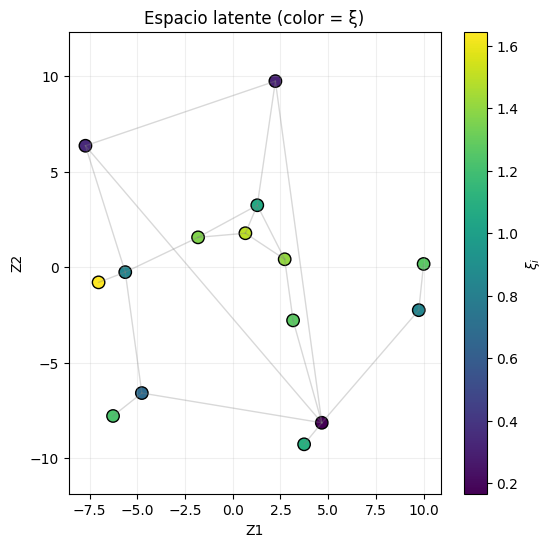

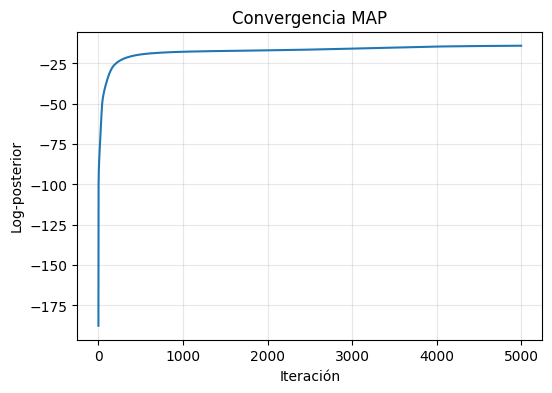

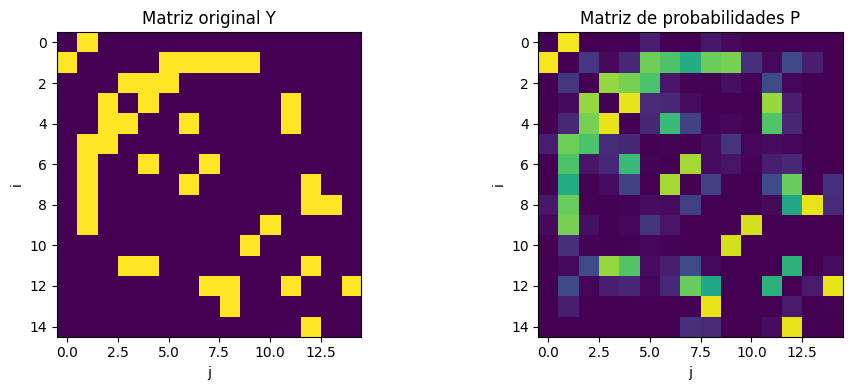

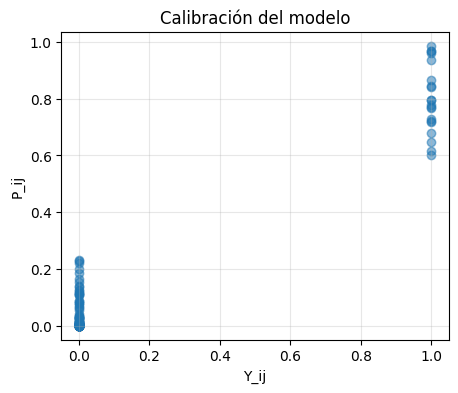

In [21]:

geometry = EuclideanGeometry(d=2, D=20.0)

model = LatentSpaceModel(Y=Y, geometry=geometry)
inference = MAPInference( model, lr=5e-2)
result = inference.fit_multi_start(n_starts=4,n_iter=5000, use_tqdm=False)
summary = inference.summary()
print("\nLog-posterior final:", summary["final_logpost"])
params = summary["final_params"]
alpha0 = params["alpha0"]
xi = params["xi"]
Z = params["Z"]
print("alpha0:", alpha0)
print("xi:", xi)
print("Z:", Z)

#################################################33

Z_np = np.array(Z)
xi_np = np.array(xi)
Y_np = np.array(Y)

plt.figure(figsize=(6,6))

# Dibujar edges
n = Y_np.shape[0]
for i in range(n):
    for j in range(i+1, n):
        if Y_np[i, j] == 1:
            plt.plot(
                [Z_np[i, 0], Z_np[j, 0]],
                [Z_np[i, 1], Z_np[j, 1]],
                color="gray",
                alpha=0.3,
                linewidth=1
            )

# Dibujar nodos
sc = plt.scatter(
    Z_np[:, 0],
    Z_np[:, 1],
    c=xi_np,
    cmap="viridis",
    s=80,
    edgecolor="black"
)

plt.colorbar(sc, label=r"$\xi_i$")
plt.title("Espacio latente (color = ξ)")
plt.xlabel("Z1")
plt.ylabel("Z2")
plt.axis("equal")
plt.grid(alpha=0.2)

plt.show()

logpost = inference.history["logpost"]

plt.figure(figsize=(6,4))
plt.plot(logpost)
plt.xlabel("Iteración")
plt.ylabel("Log-posterior")
plt.title("Convergencia MAP")
plt.grid(alpha=0.3)
plt.show()


from scipy.special import expit

# =========================
# Matriz de probabilidades
# =========================

n = Z_np.shape[0]
P = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        if i != j:
            # distancia euclidiana (consistente con tu geometry actual)
            dij = np.linalg.norm(Z_np[i] - Z_np[j])
            
            sij = alpha0 - 0.5 * (xi_np[i] + xi_np[j]) * dij
            P[i, j] = expit(sij)

# =========================
# Plot comparación
# =========================

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Matriz observada
im0 = axes[0].imshow(Y_np, vmin=0, vmax=1, cmap="viridis")
axes[0].set_title("Matriz original Y")
axes[0].set_xlabel("j")
axes[0].set_ylabel("i")

# Matriz de probabilidades
im1 = axes[1].imshow(P, vmin=0, vmax=1, cmap="viridis")
axes[1].set_title("Matriz de probabilidades P")
axes[1].set_xlabel("j")
axes[1].set_ylabel("i")


plt.tight_layout()
plt.show()

plt.figure(figsize=(5,4))
plt.scatter(Y_np.flatten(), P.flatten(), alpha=0.3)
plt.xlabel("Y_ij")
plt.ylabel("P_ij")
plt.title("Calibración del modelo")
plt.grid(alpha=0.3)
plt.show()

Modelo euclideano sin pesos

MAP: 100%|██████████| 5000/5000 [01:27<00:00, 56.93it/s, logpost=-33.9022, loglik=-32.0274, logprior=-1.8748, patience=0] 



Best log-posterior: -22.8647

Log-posterior final: -33.902164459228516
alpha0: 4.1265054
xi: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Z: [[ 4.4926753  -4.039718  ]
 [ 0.6136794  -1.551859  ]
 [-7.257987   -3.726752  ]
 [-6.631077   -6.871852  ]
 [-5.5070457  -5.8932858 ]
 [-5.3178296  -0.44545543]
 [-1.9128867  -3.3672006 ]
 [-0.2867068  -4.122973  ]
 [ 0.12834087  0.7210087 ]
 [ 5.0750723   0.5726272 ]
 [ 7.426967    0.9562251 ]
 [-4.0438128  -8.290817  ]
 [-0.04566481 -6.9342766 ]
 [-0.03650238  4.016849  ]
 [ 1.8439834  -9.553821  ]]


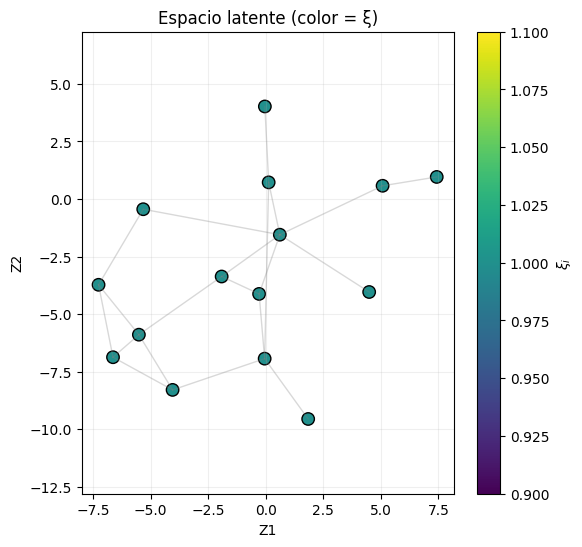

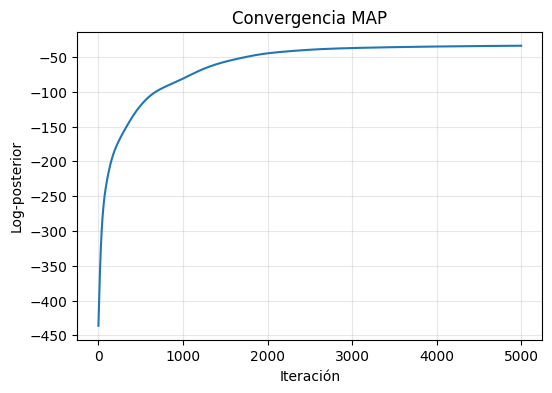

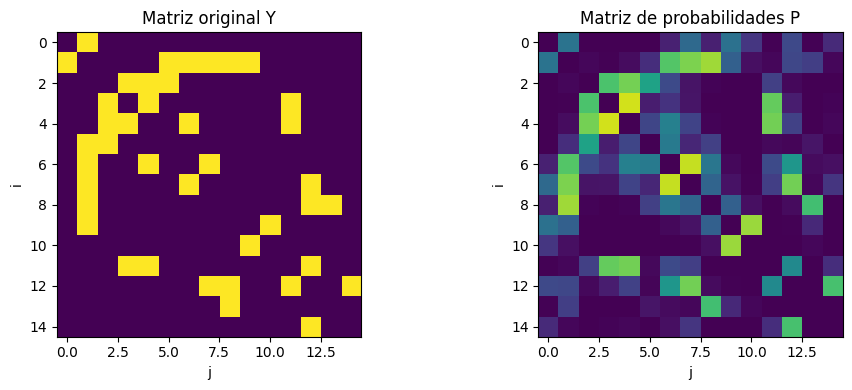

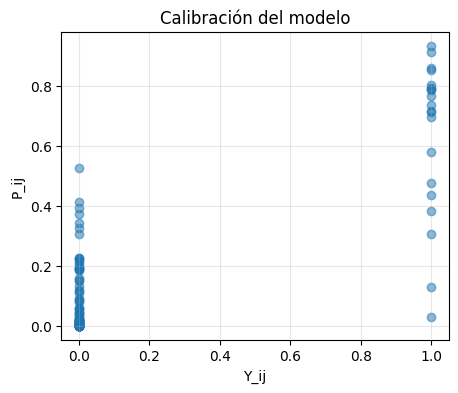

In [22]:

geometry = EuclideanGeometry(d=2, D=50.0)

model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi":jnp.ones(15)})
inference = MAPInference( model, lr=1e-2)
result = inference.fit_multi_start(n_starts=2,n_iter=5000, use_tqdm=False)
summary = inference.summary()
print("\nLog-posterior final:", summary["final_logpost"])
params = summary["final_params"]
alpha0 = params["alpha0"]
xi = params["xi"]
Z = params["Z"]
print("alpha0:", alpha0)
print("xi:", xi)
print("Z:", Z)

#################################################33

Z_np = np.array(Z)
xi_np = np.array(xi)
Y_np = np.array(Y)

plt.figure(figsize=(6,6))

# Dibujar edges
n = Y_np.shape[0]
for i in range(n):
    for j in range(i+1, n):
        if Y_np[i, j] == 1:
            plt.plot(
                [Z_np[i, 0], Z_np[j, 0]],
                [Z_np[i, 1], Z_np[j, 1]],
                color="gray",
                alpha=0.3,
                linewidth=1
            )

# Dibujar nodos
sc = plt.scatter(
    Z_np[:, 0],
    Z_np[:, 1],
    c=xi_np,
    cmap="viridis",
    s=80,
    edgecolor="black"
)

plt.colorbar(sc, label=r"$\xi_i$")
plt.title("Espacio latente (color = ξ)")
plt.xlabel("Z1")
plt.ylabel("Z2")
plt.axis("equal")
plt.grid(alpha=0.2)

plt.show()

logpost = inference.history["logpost"]

plt.figure(figsize=(6,4))
plt.plot(logpost)
plt.xlabel("Iteración")
plt.ylabel("Log-posterior")
plt.title("Convergencia MAP")
plt.grid(alpha=0.3)
plt.show()


from scipy.special import expit

# =========================
# Matriz de probabilidades
# =========================

n = Z_np.shape[0]
P = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        if i != j:
            # distancia euclidiana (consistente con tu geometry actual)
            dij = np.linalg.norm(Z_np[i] - Z_np[j])
            
            sij = alpha0 - 0.5 * (xi_np[i] + xi_np[j]) * dij
            P[i, j] = expit(sij)

# =========================
# Plot comparación
# =========================

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Matriz observada
im0 = axes[0].imshow(Y_np, vmin=0, vmax=1, cmap="viridis")
axes[0].set_title("Matriz original Y")
axes[0].set_xlabel("j")
axes[0].set_ylabel("i")

# Matriz de probabilidades
im1 = axes[1].imshow(P, vmin=0, vmax=1, cmap="viridis")
axes[1].set_title("Matriz de probabilidades P")
axes[1].set_xlabel("j")
axes[1].set_ylabel("i")


plt.tight_layout()
plt.show()

plt.figure(figsize=(5,4))
plt.scatter(Y_np.flatten(), P.flatten(), alpha=0.3)
plt.xlabel("Y_ij")
plt.ylabel("P_ij")
plt.title("Calibración del modelo")
plt.grid(alpha=0.3)
plt.show()

In [28]:
geometry = HyperbolicGeometry(d=2, D=5.0)

model = LatentSpaceModel(Y=Y, geometry=geometry)
inference = MAPInference( model, lr=1e-4)
result = inference.fit_multi_start(n_starts=2,n_iter=50000, use_tqdm=False)
summary = inference.summary()
print("\nLog-posterior final:", summary["final_logpost"])
params = summary["final_params"]
alpha0 = params["alpha0"]
xi = params["xi"]
Z = params["Z"]
print("alpha0:", alpha0)
print("xi:", xi)
print("Z:", Z)


MAP:  17%|█▋        | 8285/50000 [01:39<08:18, 83.62it/s, logpost=-59.0451, loglik=-54.7142, logprior=-4.3309, patience=49] 


[STOP] Early stopping at iter 8285 (no improvement in 50 steps)


MAP:  19%|█▉        | 9555/50000 [01:52<07:54, 85.27it/s, logpost=-42.9042, loglik=-39.1337, logprior=-3.7705, patience=49]


[STOP] Early stopping at iter 9555 (no improvement in 50 steps)

Best log-posterior: -42.9042

Log-posterior final: -42.90422058105469
alpha0: 0.4455822
xi: [1.5651331  0.21784154 0.68282956 0.7574321  0.42732972 0.80088174
 0.38985613 0.4937757  1.140128   1.0769446  1.3611094  0.8840596
 0.9614845  1.9252151  2.3159783 ]
Z: [[ 3.5000367  -1.0786729   3.9933472 ]
 [ 3.4998474  -1.0797834   3.9934816 ]
 [-0.47117606  3.6321976   3.9934816 ]
 [-2.4250045   2.744853    3.9934816 ]
 [-1.7663465   3.2085645   3.9934816 ]
 [-0.54356205  0.1308341   1.6868417 ]
 [ 0.26674533 -3.554676    3.9038308 ]
 [-1.7095072  -3.2392054   3.9934816 ]
 [ 0.5797409  -0.193003    1.7052443 ]
 [ 0.10573827  0.10864042  1.5993859 ]
 [ 2.6419973   1.6714001   3.5080843 ]
 [-0.24569094  0.24076983  1.6285149 ]
 [-0.1701342  -1.6994618   2.334827  ]
 [ 0.26075855 -0.03877739  1.6131325 ]
 [-0.02902551 -1.588237    2.2487788 ]]


True


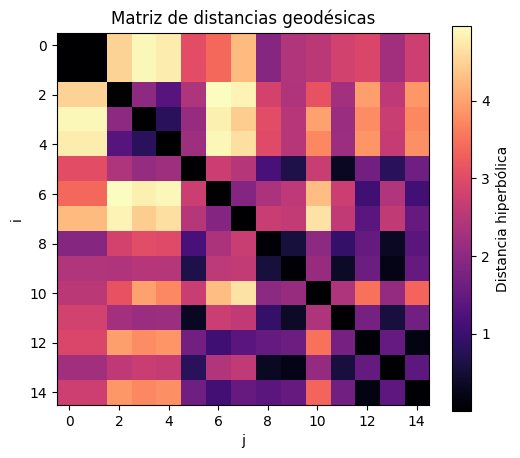

In [29]:
Dmat = geometry.distance_matrix(Z)
Dmat_np = np.array(Dmat)
print(np.max(Dmat_np)<=20.0)
plt.figure(figsize=(6,5))

plt.imshow(Dmat_np, cmap="magma")
plt.colorbar(label="Distancia hiperbólica")

plt.title("Matriz de distancias geodésicas")
plt.xlabel("j")
plt.ylabel("i")

plt.show()

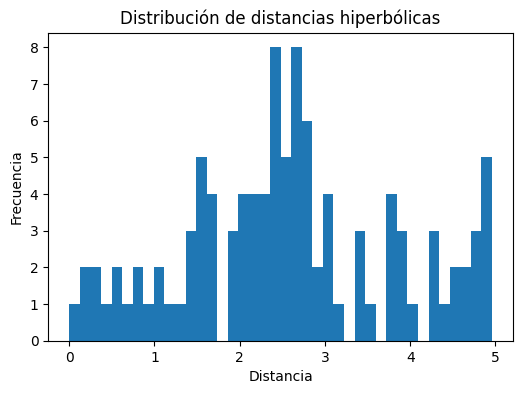

In [30]:
upper = Dmat_np[np.triu_indices_from(Dmat_np, k=1)]

plt.figure(figsize=(6,4))

plt.hist(upper, bins=40)

plt.xlabel("Distancia")
plt.ylabel("Frecuencia")

plt.title("Distribución de distancias hiperbólicas")

plt.show()

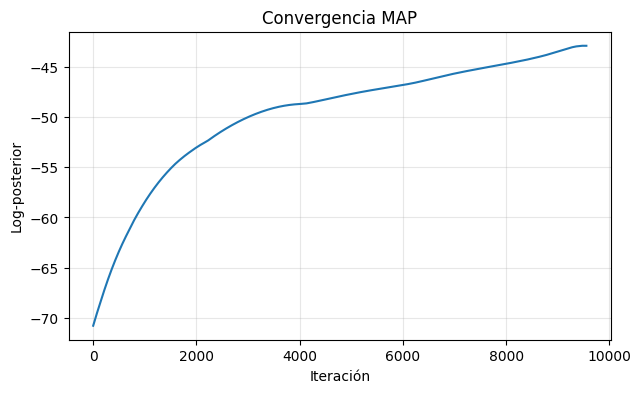

In [31]:
logpost = np.array(inference.history["logpost"])

plt.figure(figsize=(7,4))

plt.plot(logpost)

plt.xlabel("Iteración")
plt.ylabel("Log-posterior")

plt.title("Convergencia MAP")

plt.grid(alpha=0.3)

plt.show()

#### MCMC

In [ ]:
class MCMCInference(BaseInference):
    def __init__(self, model, eps_alpha0=1e-2, eps_xi=1e-2, eps_Z=1e-2, target_accept_alpha0=0.57, target_accept_xi=0.57, target_accept_Z=0.57):
        super().__init__(model)
        self.eps_alpha0 = eps_alpha0
        self.eps_xi = eps_xi
        self.eps_Z = eps_Z
        self.target_alpha0 = target_accept_alpha0
        self.target_xi = target_accept_xi
        self.target_Z = target_accept_Z
        self.geometry = self.model.geometry
        self.model.inference_method = "MCMC"
    # Log q
    def _log_q(self, x_new, x, grad_x, eps):
        mean = x + 0.5 * eps**2 * grad_x
        diff = x_new - mean
        return -0.5 * jnp.sum(diff**2) / (eps**2)

    def _log_q_manifold(self, z_new, z, grad_z, eps):
        v = self.geometry.logaritmic_map(z, z_new)
        mean = 0.5 * eps**2 * grad_z
        diff = v - mean
        return -0.5 * jnp.sum(diff**2) / (eps**2)

    # Adapt step size (Robbins–Monro)
    def _adapt(self, eps, accept, target, t):
        gamma = (t + 1) ** (-0.6)
        log_eps = jnp.log(eps) + gamma * (accept - target)
        return jnp.exp(log_eps)

    # Steps
    def step_alpha0(self, key):
        eps = self.eps_alpha0 #tau
        p = self.model.get_params()
        alpha0 = p["alpha0"]
        grad = self.model.grad_log_posterior()["alpha0"]
        key1, key2 = jax.random.split(key)
        noise = jax.random.normal(key1)
        prop = alpha0 + 0.5 * eps**2 * grad + eps * noise
        logp_current = self.model.log_posterior()
        self.model.latent_params["alpha0"] = prop
        logp_prop = self.model.log_posterior()
        grad_prop = self.model.grad_log_posterior()["alpha0"]
        log_q_f = self._log_q(prop, alpha0, grad, eps)
        log_q_b = self._log_q(alpha0, prop, grad_prop, eps)
        log_accept = logp_prop + log_q_b - logp_current - log_q_f
        if jnp.log(jax.random.uniform(key2)) < log_accept:
            return 1.0
        else:
            self.model.latent_params["alpha0"] = alpha0
            return 0.0

    def step_xi(self, key):
        eps = self.eps_xi
        p = self.model.get_params()
        xi = p["xi"]
        grad = self.model.grad_log_posterior()["xi"]
        simplex = self.model.weights
        grad = simplex.project_to_tangent(xi, grad)
        key1, key2 = jax.random.split(key)
        noise = jax.random.normal(key1, shape=xi.shape)
        noise = simplex.project_to_tangent(xi, noise)
        v = 0.5 * eps**2 * grad + eps * noise
        xi_prop = simplex.exponential_map(xi, v)
        xi_prop = simplex.project_to_domain(xi_prop)
        logp_current = self.model.log_posterior()
        self.model.latent_params["xi"] = xi_prop
        logp_prop = self.model.log_posterior()
        grad_prop = self.model.grad_log_posterior()["xi"]
        grad_prop = simplex.project_to_tangent(xi_prop, grad_prop)
        log_q_f = self._log_q(xi_prop, xi, grad, eps)
        log_q_b = self._log_q(xi, xi_prop, grad_prop, eps)
        log_accept = logp_prop + log_q_b - logp_current - log_q_f
        if jnp.log(jax.random.uniform(key2)) < log_accept:
            return 1.0
        else:
            self.model.latent_params["xi"] = xi
            return 0.0
        
    def step_Z(self, key):
        eps = self.eps_Z
        geom = self.model.geometry
        Z = self.model.get_params()["Z"]
        n = Z.shape[0]
        keys = jax.random.split(key, n)
        accepted = 0.0
        for i in range(n):
            zi = Z[i]
            grad = self.model.grad_log_posterior()["Z"][i]
            grad = geom.project_to_tangent(zi, grad)
            key1, key2 = jax.random.split(keys[i])
            noise = jax.random.normal(key1, shape=zi.shape)
            noise = geom.project_to_tangent(zi, noise)
            v = 0.5 * eps**2 * grad + eps * noise
            zi_prop = geom.exponential_map(zi, v)
            zi_prop = geom.project_to_domain(zi_prop)
            Z_prop = Z.at[i].set(zi_prop)
            logp_current = self.model.log_posterior()
            self.model.latent_params["Z"] = Z_prop
            logp_prop = self.model.log_posterior()
            grad_prop = self.model.grad_log_posterior()["Z"][i]
            grad_prop = geom.project_to_tangent(zi_prop, grad_prop)
            log_q_f = self._log_q_manifold(zi_prop, zi, grad, eps)
            log_q_b = self._log_q_manifold(zi, zi_prop, grad_prop, eps)
            log_accept = logp_prop + log_q_b - logp_current - log_q_f
            if jnp.log(jax.random.uniform(key2)) < log_accept:
                Z = Z_prop
                accepted += 1.0
            else:
                self.model.latent_params["Z"] = Z
        self.model.latent_params["Z"] = Z
        return accepted / n

    def fit(self, n_samples=1000, burnin=1000, thin=1, seed=0, verbose=True, Z_ref=None, init_params={}):
        if init_params:
            self.model.latent_params = {k: v for k, v in init_params.items() if k not in self.model.fixed_params}
        else:
            self.model.initialize_from_prior(n=self.model.Y.shape[0], seed=seed)
        key = jax.random.PRNGKey(seed)
        total_iters = burnin + n_samples * thin
        samples = []
        self.history = {"logpost": [], "loglik": [], "logprior": [],
                        "eps": {"alpha0": [], "xi": [], "Z": []}, 
                        "acceptance": {"alpha0": [], "xi": [], "Z": []}}
        self.Z_ref = Z_ref
        self._Z_ref_initialized = Z_ref is not None
        iterator = tqdm(range(total_iters), desc="MCMC") if verbose else range(total_iters)
        self.sample_logpost = []
        for t in iterator:
            key, subkey = jax.random.split(key)
            k1, k2, k3 = jax.random.split(subkey, 3)
            acc_a = self.step_alpha0(k1) if "alpha0" in self.model.latent_params else 1.0
            acc_x = self.step_xi(k2) if "xi" in self.model.latent_params else 1.0
            acc_z = self.step_Z(k3) if "Z" in self.model.latent_params else 1.0

            if (not self._Z_ref_initialized) and (t == burnin):
                self.Z_ref = self.model.get_params()["Z"]
                self._Z_ref_initialized = True

            if self._Z_ref_initialized:
                Z = self.model.latent_params["Z"]
                Z = self.geometry.identifiability_transform(Z, self.Z_ref)
                self.model.latent_params["Z"] = Z


            self.history["acceptance"]["alpha0"].append(float(acc_a))
            self.history["acceptance"]["xi"].append(float(acc_x))
            self.history["acceptance"]["Z"].append(float(acc_z))

            if t < burnin:
                self.eps_alpha0 = self._adapt(self.eps_alpha0, acc_a, self.target_alpha0, t)
                self.eps_xi     = self._adapt(self.eps_xi, acc_x, self.target_xi, t)
                self.eps_Z      = self._adapt(self.eps_Z, acc_z, self.target_Z, t)
            loglik = self.model.log_likelihood()
            logprior = self.model.log_prior()
            logpost = loglik + logprior  #self.model.log_posterior()
            self.history["loglik"].append(float(loglik))
            self.history["logprior"].append(float(logprior))
            self.history["logpost"].append(float(logpost))
            self.history["eps"]["alpha0"].append(float(self.eps_alpha0))
            self.history["eps"]["xi"].append(float(self.eps_xi))
            self.history["eps"]["Z"].append(float(self.eps_Z))


            if t >= burnin and ((t - burnin) % thin == 0):
                samples.append({ k: v.copy() if hasattr(v, "copy") else v for k, v in self.model.get_params().items()})
                self.sample_logpost.append(float(logpost))
            if verbose:
                acc_total = 0.0
                acc_total += np.mean(np.array(self.history["acceptance"]["alpha0"]))
                acc_total += np.mean(np.array(self.history["acceptance"]["xi"]))
                acc_total += np.mean(np.array(self.history["acceptance"]["Z"]))
                acc_total /= 3
                iterator.set_postfix({"logpost": f"{logpost:.3f}", "loglik": f"{loglik:.3f}", "logprior": f"{logprior:.3f}",
                                       "acceptance": f"{acc_total:.3f}"})

        self.samples = samples
        self.compute_mcmc_diagnostics()
        self._store_in_model()
        return samples
    
    def compute_waic(self):
        Y = self.model.Y
        loglik_samples = []
        for sample in self.samples:
            alpha0 = sample["alpha0"]
            xi = sample["xi"]
            Z = sample["Z"]
            Dmat = self.model.geometry.distance_matrix(Z)
            S = alpha0 - 0.5 * (xi[:, None] + xi[None, :]) * Dmat
            P = jax.nn.sigmoid(S)
            P = jnp.clip(P, 1e-12,1.0 - 1e-12)
            loglik_ij = Y * jnp.log(P) + (1.0 - Y) * jnp.log(1.0 - P)
            loglik_samples.append(loglik_ij)
        L = jnp.stack(loglik_samples, axis=0)
        lppd = jnp.sum(jnp.log(jnp.mean(jnp.exp(L),axis=0)))
        p_waic = jnp.sum(jnp.var(L, axis=0,ddof=1))
        waic = -2.0 * (lppd - p_waic)
        return float(waic)

    def _acf(self, x, max_lag=None):
        x = np.asarray(x, dtype=float)
        n = len(x)
        if max_lag is None:
            max_lag = min(n // 2, 100)
        x = x - np.mean(x)
        var = np.var(x)
        if var < 1e-12:
            return np.ones(max_lag + 1)
        acf = np.empty(max_lag + 1)
        for k in range(max_lag + 1):
            acf[k] = np.sum(x[:n-k] * x[k:]) / ((n-k) * var)
        return acf
    
    def _ess(self, x):
        x = np.asarray(x, dtype=float)
        n = len(x)
        acf = self._acf(x)
        s = 0.0
        for rho in acf[1:]:
            if rho <= 0:
                break
            s += rho
        return n / (1.0 + 2.0 * s)

    def _mcse_mean(self, x):
        x = np.asarray(x, dtype=float)
        ess = self._ess(x)
        return np.sqrt(np.var(x, ddof=1) / ess)
    
    def compute_mcmc_diagnostics(self):
        diagnostics = {"acf": {}, "ess": {}, "mcse": {}, "summary": {}}
        # alpha0
        if "alpha0" in self.samples[0]:
            chain = np.array([float(s["alpha0"]) for s in self.samples])
            diagnostics["acf"]["alpha0"] = self._acf(chain)
            diagnostics["ess"]["alpha0"] = self._ess(chain)
            diagnostics["mcse"]["alpha0"] = self._mcse_mean(chain)
            diagnostics["summary"]["alpha0"] = diagnostics["ess"]["alpha0"]
            diagnostics["summary"]["mcse"] = diagnostics["mcse"]["alpha0"]
        # xi
        if "xi" in self.samples[0]:
            xi_chain = np.array([np.asarray(s["xi"]) for s in self.samples])
            p = xi_chain.shape[1]
            diagnostics["acf"]["xi"] = []
            diagnostics["ess"]["xi"] = np.zeros(p)
            diagnostics["mcse"]["xi"] = np.zeros(p)
            for j in range(p):
                chain = xi_chain[:, j]
                diagnostics["acf"]["xi"].append(self._acf(chain))
                diagnostics["ess"]["xi"][j] = self._ess(chain)
                diagnostics["mcse"]["xi"][j] = self._mcse_mean(chain)
            diagnostics["acf"]["xi"] = np.array(diagnostics["acf"]["xi"])
            diagnostics["summary"]["xi"] = np.min(diagnostics["ess"]["xi"])
            diagnostics["summary"]["mcse"] = np.max(diagnostics["mcse"]["xi"])
        # Z
        if "Z" in self.samples[0]:
            Z_chain = np.array([np.asarray(s["Z"]) for s in self.samples])
            n_nodes = Z_chain.shape[1]
            dplus1 = Z_chain.shape[2]
            diagnostics["acf"]["Z"] = np.empty((n_nodes, dplus1), dtype=object)
            diagnostics["ess"]["Z"] = np.zeros((n_nodes, dplus1))
            diagnostics["mcse"]["Z"] = np.zeros((n_nodes, dplus1))
            for i in range(n_nodes):
                for j in range(dplus1):
                    chain = Z_chain[:, i, j]
                    diagnostics["acf"]["Z"][i, j] = self._acf(chain)
                    diagnostics["ess"]["Z"][i, j] = self._ess(chain)
                    diagnostics["mcse"]["Z"][i,j] = (self._mcse_mean(chain))
            diagnostics["summary"]["Z"] = np.min(diagnostics["ess"]["Z"])
            diagnostics["summary"]["mcse"] = np.max(diagnostics["mcse"]["Z"])
        
        self.diagnostics = diagnostics
        return diagnostics

    def _store_in_model(self):
        diagnostics = self.diagnostics
        # Posterior mean estimate
        posterior_mean = {}
        # alpha0
        posterior_mean["alpha0"] = jnp.mean(jnp.array([s["alpha0"] for s in self.samples]))
        # xi
        xi_mean = jnp.mean(jnp.stack([s["xi"] for s in self.samples]), axis=0)
        xi_mean = self.model.weights.project_to_domain(xi_mean)
        posterior_mean["xi"] = xi_mean
        # Z
        Z_mean = jnp.mean(jnp.stack([s["Z"] for s in self.samples]), axis=0)
        Z_mean = jax.vmap(self.model.geometry.project_to_domain)(Z_mean)
        posterior_mean["Z"] = Z_mean
        # MAP estimate
        map_idx = np.argmax(self.sample_logpost)
        posterior_map = {k: (self.samples[map_idx][k].copy() if hasattr(self.samples[map_idx][k], "copy") else self.samples[map_idx][k])
            for k in self.samples[map_idx]}
        # Matrices from posterior mean
        alpha0_cm = posterior_mean["alpha0"]
        xi_cm = posterior_mean["xi"]
        Z_cm = posterior_mean["Z"]
        Dmat_cm = self.model.geometry.distance_matrix(Z_cm)
        S_cm = alpha0_cm - 0.5 * (xi_cm[:, None] + xi_cm[None, :]) * Dmat_cm
        P_cm = jax.nn.sigmoid(S_cm)
        # Matrices from MAP
        alpha0_map = posterior_map["alpha0"]
        xi_map = posterior_map["xi"]
        Z_map = posterior_map["Z"]
        Dmat_map = self.model.geometry.distance_matrix(Z_map)
        S_map = alpha0_map - 0.5 * (xi_map[:, None] + xi_map[None, :]) * Dmat_map
        P_map = jax.nn.sigmoid(S_map)
        # Information criterion
        waic = self.compute_waic()
        # Store
        self.model.inferred["MCMC"] = {
            # posterior samples
            "samples": self.samples,
            "sample_logpost": self.sample_logpost,
            # posterior mean
            "posterior_mean": posterior_mean,
            # MAP
            "posterior_map": posterior_map,
            # diagnostics
            "diagnostics": diagnostics,
            # information criterion
            "waic": waic,
            # history
            "history": self.history,
            # tuning parameters
            "eps": {"alpha0": self.eps_alpha0, "xi": self.eps_xi, "Z": self.eps_Z },
            # acceptance rates
            "acceptance": {"alpha0": self.history["acceptance"]["alpha0"],
                "xi": self.history["acceptance"]["xi"],
                "Z": self.history["acceptance"]["Z"],
                "alpha0_mean": np.mean(self.history["acceptance"]["alpha0"]),
                "xi_mean": np.mean(self.history["acceptance"]["xi"]),
                "Z_mean": np.mean(self.history["acceptance"]["Z"])},
            # geometry information
            "geometry": type(self.model.geometry).__name__,
            "dimension": self.model.geometry.d,
            "diameter": getattr(self.model.geometry,"D",None),
            # CM matrices
            "Dmat_cm": Dmat_cm,
            "S_cm": S_cm,
            "P_cm": P_cm,
            # MAP matrices
            "Dmat_map": Dmat_map,
            "S_map": S_map,
            "P_map": P_map}

In [15]:

geometry = EuclideanGeometry(d=2, D=5.0)
#geometry = SphericalGeometry(d=2, D=5.0)
#geometry = HyperbolicGeometry(d=2, D=5.0)

model = LatentSpaceModel(Y=Y, geometry=geometry)
inference = MCMCInference(model)
result = inference.fit(n_samples=100, burnin=100, thin=1)

MCMC: 100%|██████████| 200/200 [00:55<00:00,  3.59it/s, logpost=-45.623, loglik=-39.514, logprior=-6.108, acceptance=0.668] 


In [56]:
inference

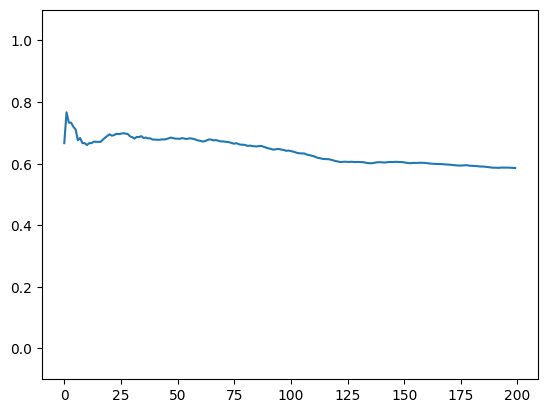

In [50]:
plt.plot(jnp.cumsum(jnp.array(inference.history['acceptance']['Z'])) / jnp.array(range(1,201)))
plt.ylim(-0.1,1.1)
plt.show()

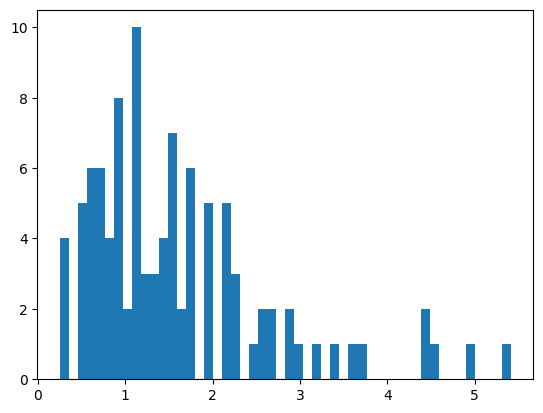

In [53]:
plt.hist(np.array([result[l]['xi'] for l in range(100)])[:,10],bins=50)
plt.show()

### Analysis

In [ ]:
class ModelAnalysis:
    # Initialization
    def __init__(self, model, inference_key="MAP"):
        self.model = model
        self.inference_key = inference_key
        # inferred object
        self.results = model.inferred[inference_key]
        # observed data
        self.Y = np.array(model.Y)
        # geometry
        self.geometry = model.geometry
        # inferred quantities
        self.params = self.results["final_params"]
        self.alpha0 = self.params["alpha0"]
        self.xi = np.array(self.params["xi"])
        self.Z = np.array(self.params["Z"])
        # derived matrices
        self.Dmat = np.array(self.results["Dmat"])
        self.P = np.array(self.results["P"])
        # optimization history
        self.history = self.results["history"]
        # dimensions
        self.n = self.Y.shape[0]
        self.d = self.geometry.d

    # SECTION 1: Latent space visualization
    def plot_latent_space(self, weighted=False, labels=True, node_size=50, cmap="viridis"):
        """
        Plot latent space embedding.
        Parameters
        ----------
        weighted : bool
            If True, node size/color depends on xi.
        labels : bool
            Show node labels.
        node_size : int
            Base node size.
        cmap : str
            Colormap.
        """
        pass

    # SECTION 2: Matrix visualizations
    def plot_matrix(self, matrix, title="", cmap="viridis", compare_Y=False):
        """
        Generic matrix visualization with colorbar.
        """
        pass
    def plot_probability_matrix(self):
        """
        Plot inferred probability matrix.
        """
        pass
    def plot_distance_matrix(self):
        """
        Plot geodesic distance matrix.
        """
        pass
    def plot_score_matrix(self):
        """
        Plot latent score matrix.
        """
        pass
    def compare_with_adjacency(self, matrix, title=""):
        """
        Compare inferred matrix against adjacency matrix.
        """
        pass

    # SECTION 3: Optimization diagnostics
    def plot_logposterior_trace(self):
        """
        Optimization convergence diagnostics.
        """
        pass
    def plot_gradient_norms(self):
        """
        Gradient norm diagnostics.
        """
        pass
    def plot_parameter_trace(self, parameter="alpha0"):
        """
        Trace plot for parameter evolution.
        """
        pass
    def optimization_summary(self):
        """
        Scalar optimization diagnostics.
        """
        pass

    # SECTION 4: Scalar fit metrics
    def log_likelihood(self):
        """
        Final log-likelihood.
        """
        pass
    def waic(self):
        """
        WAIC approximation.
        """
        pass
    def fit_summary(self):
        """
        Table of scalar fit metrics.
        """
        pass
    
    # SECTION 5: Internal validation
    def network_statistics(self):
        """
        Compute observed network statistics.

        Example:
        - density
        - transitivity
        - clustering
        - assortativity
        - average degree
        - average shortest path
        - modularity
        - degree variance
        """
        pass
    def posterior_predictive_check(self, n_sim=100):
        """
        Posterior predictive checks.
        """
        pass
    def posterior_predictive_pvalues(self,n_sim=100):
        """
        Posterior predictive p-values.
        """
        pass
    def plot_ppc_distributions(self, n_sim=100):
        """
        PPC histogram diagnostics.
        """
        pass


    # SECTION 6: Binary prediction diagnostics
    def binary_prediction_metrics(self, threshold=0.5):
        """
        Binary prediction metrics.
        Example:
        - ROC-AUC
        - accuracy
        - precision
        - recall
        - F1-score
        - balanced accuracy
        """
        pass
    def plot_roc_curve(self):
        """
        ROC curve.
        """
        pass
    def plot_precision_recall_curve(self):
        """
        Precision-recall curve.
        """
        pass
    def confusion_matrix(self, threshold=0.5):
        """
        Binary confusion matrix.
        """
        pass


    # SECTION 7: Cross-validation
    def cross_validation(self, n_folds=5, seed=42, refit=True):
        """
        K-fold cross-validation for binary prediction.
        """
        pass

    def cross_validation_summary(self):
        """
        Aggregate CV metrics.
        """
        pass

    # SECTION 8: Utilities
    def summary(self):
        """
        Global analysis summary.
        """
        pass

    def export_results(self, path):
        """
        Export analysis results.
        """
        pass

## Models over $\mathbb{R}^d$

### Model $\mathbb{R^1}$

#### With weights

#### Without weights

### Model $\mathbb{R}^2$

#### With weights

In [20]:
# MAP
geometry = EuclideanGeometry(d=2, D=10.0)
model = LatentSpaceModel(Y=Y, geometry=geometry)
map_inference = MAPInference(model,lr=1e-2)
map_result = map_inference.fit_multi_start(n_starts=10,n_iter=25000,use_tqdm=False)
map_summary = map_inference.summary()
map_params = map_summary["final_params"]
alpha0_map = map_params["alpha0"]
xi_map = map_params["xi"]
Z_map = map_params["Z"]
print("MAP logpost:", map_summary["final_logpost"])

MAP:  21%|██        | 5151/25000 [01:32<05:57, 55.46it/s, logpost=-20.7224, loglik=-17.1427, logprior=-3.5797, patience=49]


[STOP] Early stopping at iter 5151 (no improvement in 50 steps)


MAP:  68%|██████▊   | 17071/25000 [04:00<01:51, 70.92it/s, logpost=-21.3466, loglik=-18.6597, logprior=-2.6869, patience=49]


[STOP] Early stopping at iter 17071 (no improvement in 50 steps)


MAP:  46%|████▋     | 11603/25000 [02:20<02:41, 82.84it/s, logpost=-22.7259, loglik=-19.9385, logprior=-2.7874, patience=49]


...

[STOP] Early stopping at iter 8770 (no improvement in 50 steps)


MAP:  81%|████████  | 20176/25000 [04:06<00:58, 81.99it/s, logpost=-22.4973, loglik=-19.4045, logprior=-3.0928, patience=49]


[STOP] Early stopping at iter 20176 (no improvement in 50 steps)


MAP:  58%|█████▊    | 14595/25000 [03:14<02:18, 75.11it/s, logpost=-23.5129, loglik=-20.5350, logprior=-2.9779, patience=49]


[STOP] Early stopping at iter 14595 (no improvement in 50 steps)

Best log-posterior: -18.2698
MAP logpost: -23.512866973876953


In [22]:
# MCMC
map_params = map_inference.summary()["final_params"]
samples = MCMCInference(model).fit(n_samples=500, burnin=100, thin=3, seed=123, init_params=map_params, Z_ref=map_params["Z"],verbose=True)

MCMC: 100%|██████████| 1600/1600 [03:53<00:00,  6.85it/s, logpost=-46.178, loglik=-36.985, logprior=-9.193, acceptance=0.556] 


In [29]:
samples_xi = np.array([s["xi"] for s in samples])
xi_mean = np.mean(samples_xi, axis=0)
xi_mean

array([1.5488226 , 0.28842854, 1.0103127 , 1.0724694 , 0.6517644 ,
       0.9061977 , 0.61433107, 0.6482396 , 0.66502786, 1.1830802 ,
       1.7821695 , 0.7265746 , 0.46259362, 1.780725  , 1.6592628 ],
      dtype=float32)

#### Without weigths

## Models over $\mathbb{S}^d$

### Model $\mathbb{S}^1$

#### With weights

#### Without weights

### Model $\mathbb{S}^2$

#### With weights

#### Without weights

## Models over $\mathbb{H}^d$

### Model $\mathbb{H}^1$

#### With weights

#### Without weights

### Model $\mathbb{H}^2$

#### With weights

#### Without weights